Kaarina Mattika, CS87A, Section 1758
https://github.com/kmattika/cs82a-portfolio

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

Step One

In [2]:
df = pd.read_csv(r'C:\Users\kamat\OneDrive\Desktop\CS82A\chickwts.csv')
display(df.head(10))
display(df.shape)
display(df.info())
display(df.describe())

,Unnamed: 0,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean
5,6,168,horsebean
6,7,108,horsebean
7,8,124,horsebean
8,9,143,horsebean
9,10,140,horsebean


(71, 3)

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  71 non-null     int64
 1   weight      71 non-null     int64
 2   feed        71 non-null     str  
dtypes: int64(2), str(1)
memory usage: 2.3 KB


None

,Unnamed: 0,weight
count,71.000000,71.000000
mean,36.000000,261.309859
std,20.639767,78.073700
min,1.000000,108.000000
25%,18.500000,204.500000
50%,36.000000,258.000000
75%,53.500000,323.500000
max,71.000000,423.000000


In [3]:
display(df.groupby('feed')['weight'].mean().sort_values(ascending=False))

feed
sunflower    328.916667
casein       323.583333
meatmeal     276.909091
soybean      246.428571
linseed      218.750000
horsebean    160.200000
Name: weight, dtype: float64

Step Two

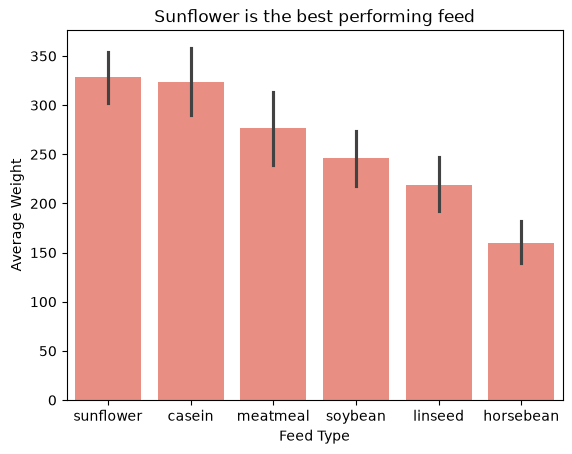

In [4]:
sns.barplot(
    data=df,
    x='feed',
    y='weight',
    order=df.groupby('feed')['weight'].mean().sort_values(ascending=False).index,
    color='salmon',
)

plt.title('Sunflower is the best performing feed')
plt.xlabel('Feed Type')
plt.ylabel('Average Weight')
plt.show()

Step Nine

With this chart, I wanted to have the highest values begin on the left side of the chart, which is often the opposite of the norm when creating visual figures like this. My reasoning is that, for slideshow meetings and individual pitch decks, these charts will be referenced several times for very short periods of time - for an English speaking audience, who naturally reads left to right, I want to put the prominent insight at the natural "reading" point, which is on the left. In other languages (namely Arabic, Hebrew, and Urdu) that read right to left, I would reverse this decision for the same effect. Aesthetically, I chose the 'salmon' color because it's my favorite fish, and because it's pleasant to look at on a white background; there is less harsh contrast for a warmer color on a white background than a cooler one, especially for analysts working late nights in a dark room as I have in the past.

Step Three

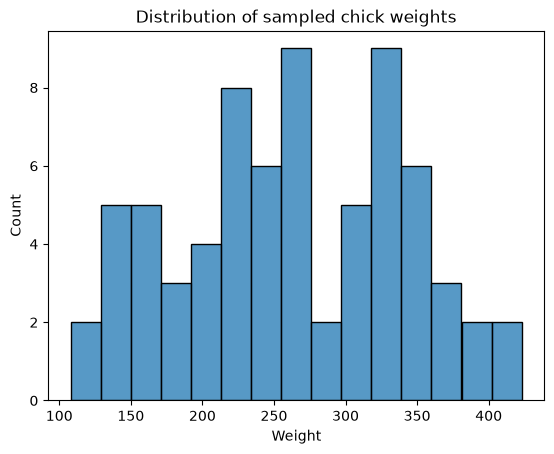

In [5]:
sns.histplot(
    data=df,
    x='weight',
    bins=15,
)

plt.title('Distribution of sampled chick weights')
plt.xlabel('Weight')
plt.ylabel('Count')
plt.show()

Step Six

In comparing the weight of chicks fed either sunflower seed or horsebean seed, the null hypothesis assumed that there is no statistically noticable difference between the weight of the chicks and the type of feed given to them.

Step Seven

In [6]:
a = df[df['feed'] == 'horsebean']['weight']
b = df[df['feed'] == 'sunflower']['weight']
ttest_ind(a, b)

TtestResult(statistic=np.float64(-8.848346742516636), pvalue=np.float64(2.3743507676837164e-08), df=np.float64(20.0))

Step Eight

The t-value has an absolute value of 8.85 when rounded to two decimal places, and the p-value has an absolute value of 0.0000000237 when rounded to ten decimal places. We can calculate the effect size by calculating Cohen's d, which I've done below:

In [7]:
print(8.848346742516636 * ((1/10 + 1/12) ** 0.5))

3.7886357281433387


Cohen's d is calculated by taking the t-test and multiplying it with the square root of the sum of 1 over n(1,2) where n is equal to the sample size of the variable tested in the t-test, with those two values added together. Written out, it sounds more complicated than it is, so the easier way to explain it is to go step by step: calculate one over the total sample size for your first variable, do the same for your second variable, then add them together and calculate the square root of the sum of those numbers, then, multiply that number by the t-test result. Here, we have a Cohen's d value of nearly four, which is a very large effect size. Coupled with a p-value significantly under the 0.05 threshold we look for to determine statistical significance, my determination is that there is a very observable and measurable difference in chick weight resulting from the type of feed provided. My caveat for this determination is that a very small sample size is more likely to produce skewed and extreme results, and that a larger sample size in the hundreds or thousands would more likely than not reduce the statistical difference of chick weights when fed horsebean or sunflower.

Step Four

In [8]:
df = pd.read_csv(r'C:\Users\kamat\OneDrive\Desktop\CS82A\museum_visitors.csv')
display(df.head(10))
display(df.shape)
display(df.info())
display(df.describe())

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694
5,2014-06-01,29487,5751,2121,11036
6,2014-07-01,32378,5406,2239,13490
7,2014-08-01,37680,8619,1769,9139
8,2014-09-01,28473,61192,1073,5661
9,2014-10-01,27995,6488,1979,7356


(59, 5)

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   Date                                  59 non-null     str  
 1   Avila Adobe                           59 non-null     int64
 2   Firehouse Museum                      59 non-null     int64
 3   Chinese American Museum               59 non-null     int64
 4   America Tropical Interpretive Center  59 non-null     int64
dtypes: int64(4), str(1)
memory usage: 3.0 KB


None

,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
count,59.000000,59.000000,59.000000,59.000000
mean,24061.661017,6472.830508,2721.254237,7107.016949
std,5948.997414,7471.196609,1165.585196,2561.671286
min,14035.000000,3306.000000,1073.000000,2824.000000
25%,19469.500000,4412.500000,2134.000000,5424.500000
50%,23136.000000,5181.000000,2419.000000,6602.000000
75%,27502.000000,6239.500000,2942.500000,7943.000000
max,41242.000000,61192.000000,7702.000000,13490.000000


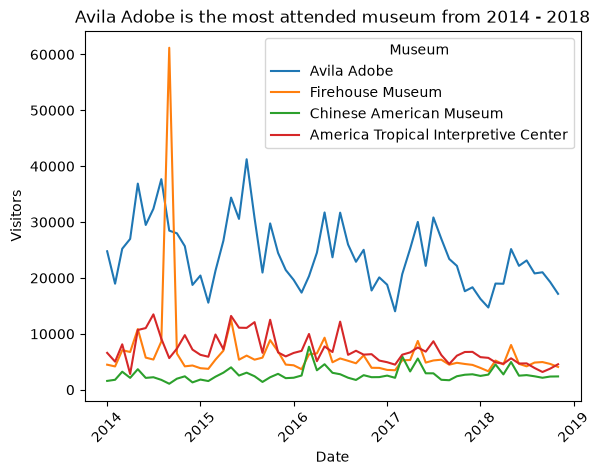

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

long_df = df.melt(
    id_vars='Date',
    var_name='Museum',
    value_name='Visitors'
)

sns.lineplot(
    data=long_df,
    x='Date',
    y='Visitors',
    hue='Museum'
)

plt.title('Avila Adobe is the most attended museum from 2014 - 2018')
plt.xticks(rotation=45)
plt.show()

The most obvious trend here is the massive spike in attendance to the Firehouse Museum in the autumn of 2014. Given that the Q3 range of that museum is a tenth of the size of that spike, my first conclusion is to investigate the data to see whether or not that is a genuine spike in attendance (and consult with the museum itself to see if that level of attendance is even physically possible). Otherwise, we see some prominent trends - the Avila Adobe is most popular during the summer, and the Chinese American Museum sees spikes in attendance overlapping with Lunar New Year. The American Tropical Interpretive Center had above average attendance in 2015, which is not replicated across other years.

Step Five

In [10]:
df = pd.read_csv(r'C:\Users\kamat\OneDrive\Desktop\CS82A\sales_clean.csv')
display(df.head(10))
display(df.shape)
display(df.info())
display(df.describe())
df['revenue'] = df['qty'] * df['price']

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405
5,1280,2026-04-22,pen set,37.53,4,30303
6,1204,2026-04-18,charger,8.41,2,2134
7,1249,2026-05-15,keyboard,75.04,4,90405
8,1037,2026-05-19,mug,9.31,2,60614
9,1177,2026-05-13,mug,10.11,3,90210


(292, 6)

<class 'pandas.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  292 non-null    int64  
 1   date      292 non-null    str    
 2   product   292 non-null    str    
 3   price     292 non-null    float64
 4   qty       292 non-null    int64  
 5   zip       292 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 18.7 KB


None

,order_id,price,qty,zip
count,292.000000,292.000000,292.000000,292.000000
mean,1145.500000,55.523151,2.986301,45463.989726
std,84.437354,71.767085,1.409279,39284.386854
min,1000.000000,2.930000,1.000000,2116.000000
25%,1072.750000,11.045000,2.000000,2134.000000
50%,1145.500000,37.530000,3.000000,30303.000000
75%,1218.250000,55.510000,4.000000,90210.000000
max,1291.000000,479.290000,5.000000,98101.000000


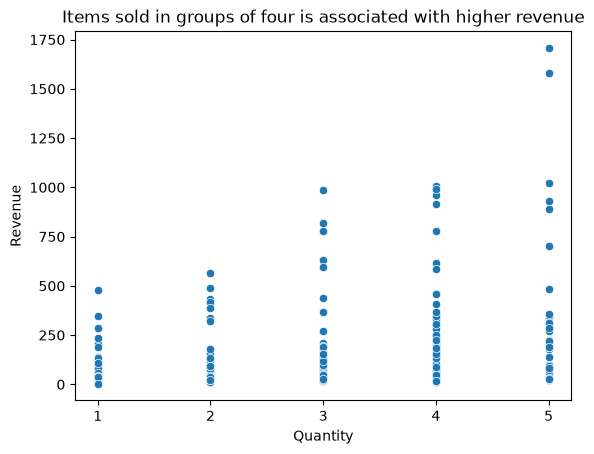

In [11]:
sns.scatterplot(
    data=df,
    x='qty',
    y='revenue',
)

plt.title('Items sold in groups of four is associated with higher revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.xticks([1, 2, 3, 4, 5])
plt.show()

<Axes: >

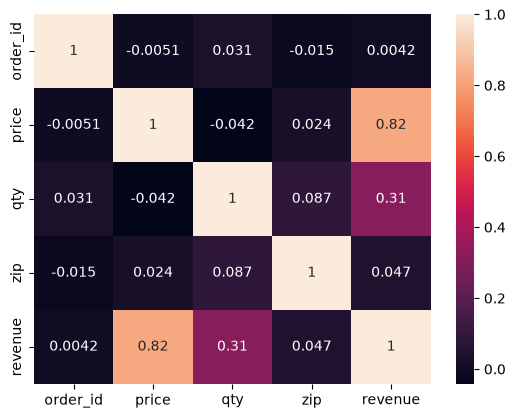

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

From the heatmap, we see a strong correlations between quantity, price, and revenue, which is expected given the first two are mathmatical inputs into the formula that provides us with revenue. From the scatterplot, the strongest phenomenon we can see is that orders in quantity of four is most strongly associated with higher revenue - orders of five are skewed by some extreme outliers and fewer trailing data points at the higher end of the revenue axis, while orders of three are clustered further down on the revenue axis (a trend also found in orders of one or two).

Appendix: 

In this assignment, I used a LLM to help with the syntax construction for Step Four. I was having difficulty getting the syntax correctly for a line chart, as I'm most used to creating charts with a clear x-y axis as opposed to a single x multiply y data source. I used GPT 5.6-Sol set to 'Medium', with the following queries:

'Where can I find a guide or tutorial for creating a line graph in Seaborn with multiple y values?'
'Can you explain the plt.xticks(rotation=30) portion of the syntax?'

While 5.6-Sol provided me with it's own tutorial that I ended up using, I did not copy and paste and of the suggested code provided as part of the tutorial. I also heavily consulted the Seaborn wiki (seaborn.pydata.org) and personal friends who have professional experience with Python.